#### SHAP

##### Importing Libraries and Loading Data

In [1]:
import numpy as np
import pandas as pd
import shap
import joblib
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

from sqlalchemy.testing.pickleable import Parent

In [20]:
project_root = Path('.').resolve().parent
fig_dir = project_root/'reports'/'figures'

In [3]:
bundle = joblib.load(project_root/'models'/'price_model.joblib')

In [4]:
model        = bundle['model']
features     = bundle['features']
encoding     = bundle['target_encoding']
global_mean  = bundle['te_global_mean']
medians      = bundle['impute_medians']

In [5]:
df = pd.read_parquet(project_root/'data'/'processed'/'london_features.parquet')

In [6]:
test = df[df['year'] == 2024].copy()

In [7]:
# Rebuilding the same features

test['district_te'] = test['postcode_district'].map(encoding).fillna(global_mean)

In [8]:
for col, med in medians.items():
    test[col] = test[col].fillna(med)

In [9]:
X_test = test[features]

##### Explainer

In [10]:
# Tree Explainer calculates SHAP values for Tree based models (XGboost, Random Forest)

explainer = shap.TreeExplainer(model)

In [11]:
# Using a sample so it's easier and faster

X_sample = X_test.sample(2000, random_state=42)

In [12]:
explanation = explainer(X_sample)

In [13]:
explanation.values.shape

(2000, 18)

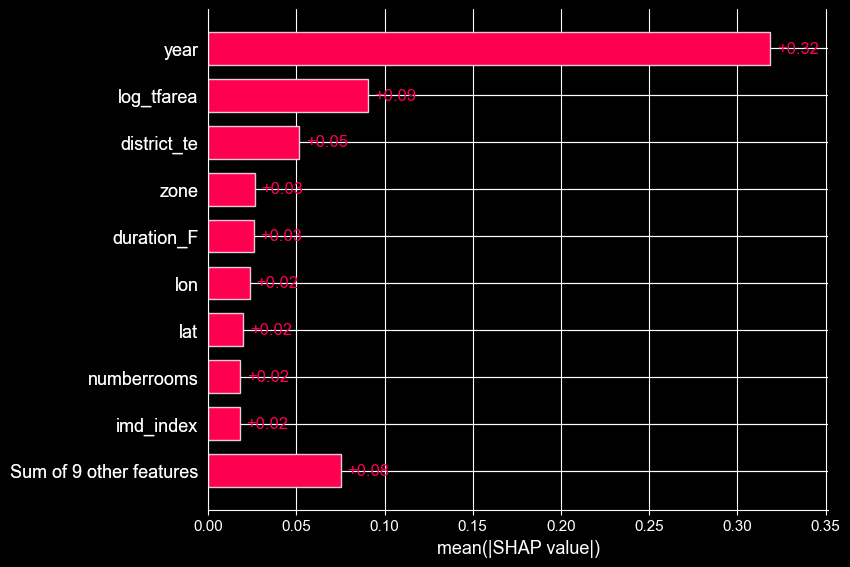

<Figure size 640x480 with 0 Axes>

<Figure size 640x480 with 0 Axes>

In [21]:
# Ranking the importance of features through a SHAP bar plot

shap.plots.bar(explanation)

plt.tight_layout()
plt.show()

plt.savefig(fig_dir/'shap_bar.png', dpi=120, bbox_inches='tight')

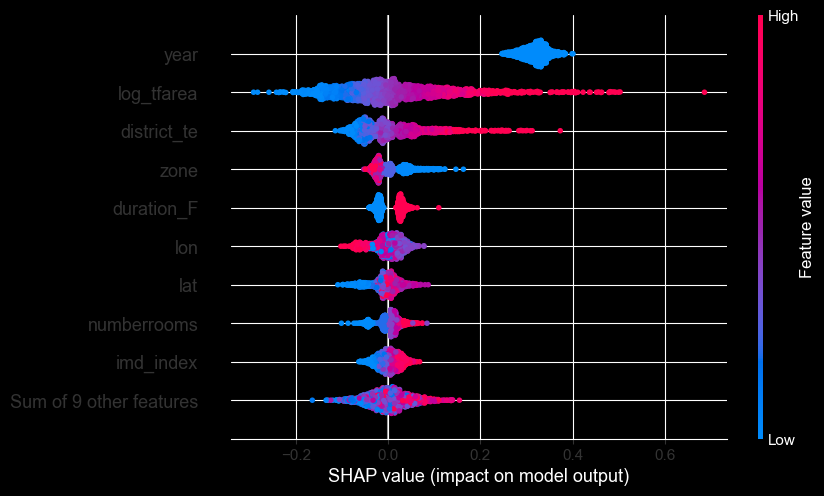

<Figure size 640x480 with 0 Axes>

<Figure size 640x480 with 0 Axes>

In [24]:
# Seeing feature importance through a beeswarm chart. Each dot is one property's SHAP value for one feature.
# Position left/right = the contribution (negative pushes price down, positive up). Color = the feature's value (red high, blue low).

shap.plots.beeswarm(explanation)

plt.tight_layout()
plt.show()

plt.savefig(fig_dir/'shap_beeswarm.png', dpi=120, bbox_inches='tight')

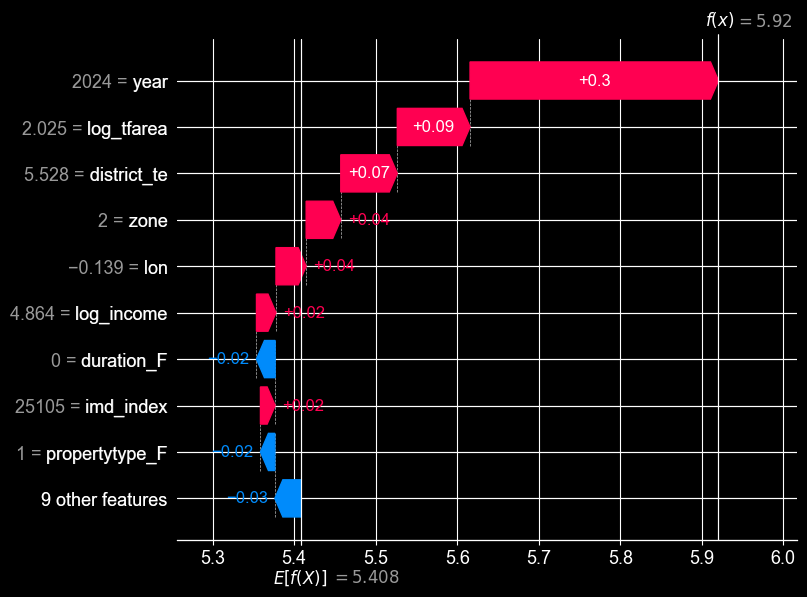

<Figure size 640x480 with 0 Axes>

<Figure size 640x480 with 0 Axes>

In [30]:
# Explaining a single prediction and property
# The waterfall starts at the base value and shows each feature stacking on top (up or down) until it reaches this property's prediction.


shap.plots.waterfall(explanation[69])

plt.tight_layout()
plt.show()

plt.savefig(fig_dir/'shap_waterfall.png', dpi=120, bbox_inches='tight')

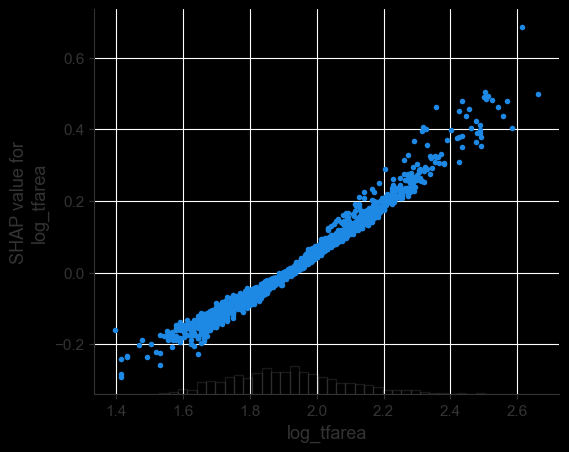

<Figure size 640x480 with 0 Axes>

<Figure size 640x480 with 0 Axes>

In [32]:
# The SHAP scatterplot shows one feature's value (x) against its SHAP value (y) across all properties.
# It shows the shape of the relationship the model learned (linear, curved etc.)

shap.plots.scatter(explanation[:, 'log_tfarea'])

plt.tight_layout()
plt.show()

plt.savefig(fig_dir/'shap_scatter.png', dpi=120, bbox_inches='tight')

In [46]:
# Exploring price prediction in GBP

row = explanation[69]
base_gbp = 10 ** row.base_values
pred_gbp = 10 ** (row.base_values + row.values.sum())
true_gbp = test.loc[X_sample.index[69], 'price']

print(f'Base (Average Property Price): £{base_gbp:,.0f}')
print(f'The Predicted Price: £{pred_gbp:,.0f}')
print(f'Actual Sale Price: £{true_gbp:,.0f}')
print(f'Error: £{pred_gbp - true_gbp:,.0f}\n')

Base (Average Property Price): £255,981
The Predicted Price: £832,577
Actual Sale Price: £875,000
Error: £-42,423

